In [ ]:
# Install required libraries for reading cloud data formats and accessing AWS public buckets
!pip install boto3 netcdf4

In [ ]:
import os
import boto3
from botocore import UNSIGNED
from botocore.config import Config
import netCDF4 as nc
import numpy as np
import torch
from torch.utils.data import Dataset

class GOES16ProxyDataset(Dataset):
    """
    Streams consecutive frame pairs directly from NOAA's public GOES-16 S3 bucket.
    Product: 'ABI-L2-CMIPC' (Cloud & Moisture Imagery - CONUS standard projection)
    Bands: 'C09' (6.9um Mid-Level Water Vapor) or 'C14' (11.2um Longwave Thermal IR)
    """
    def __init__(self, product='ABI-L2-CMIPC', band='C09', year=2025, day_of_year=150, hour=14):
        self.bucket_name = 'noaa-goes16'
        self.product = product
        self.band = band

        # Configure anonymous public access to bypass mandatory AWS credential steps
        self.s3 = boto3.client('s3', region_name='us-east-1',
                               config=Config(signature_version=UNSIGNED))

        # S3 Path syntax structure: Product/Year/Day_of_Year/Hour/
        self.prefix = f"{product}/{year}/{day_of_year:03d}/{hour:02d}/"
        self.file_list = self._get_s3_file_list()

    def _get_s3_file_list(self):
        response = self.s3.list_objects_v2(Bucket=self.bucket_name, Prefix=self.prefix)
        if 'Contents' not in response:
            raise FileNotFoundError(f"No files available matching path: s3://{self.bucket_name}/{self.prefix}")

        # Match only files containing our desired band descriptor suffix
        files = [obj['Key'] for obj in response['Contents'] if f"M6{self.band}" in obj['Key']]
        return sorted(files)

    def _download_and_parse(self, s3_key):
        local_filename = s3_key.split('/')[-1]
        if not os.path.exists(local_filename):
            print(f"Streaming {local_filename} down to Colab disk runtime...")
            self.s3.download_file(self.bucket_name, s3_key, local_filename)

        # Parse matrix metadata
        with nc.Dataset(local_filename, 'r') as rootgrp:
            data_matrix = np.array(rootgrp.variables['CMI'][:], dtype=np.float32)
            data_matrix = np.nan_to_num(data_matrix, nan=0.0)


        h, w = data_matrix.shape
        data_matrix = data_matrix[h//2-256 : h//2+256, w//2-256 : w//2+256]

        return torch.from_numpy(data_matrix).unsqueeze(0) # Shape: [1, H, W]

    def __len__(self):
        return max(0, len(self.file_list) - 1)

    def __getitem__(self, idx):
        frame_t = self._download_and_parse(self.file_list[idx])
        frame_t_next = self._download_and_parse(self.file_list[idx + 1])

        # Terrain Context layer (DEM mapping simulation) matching image geometry
        _, h, w = frame_t.shape
        mock_dem = torch.zeros((1, h, w), dtype=torch.float32)

        return frame_t, frame_t_next, mock_dem

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU(inplace=True)

        self.downsample = None
        if stride != 1 or in_planes != planes:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_planes, planes, kernel_size=1, stride=stride),
                nn.BatchNorm2d(planes)
            )
        self.bn1 = nn.BatchNorm2d(planes)
        self.bn2 = nn.BatchNorm2d(planes)

    def forward(self, x):
        residual = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            residual = self.downsample(x)
        out += residual
        return self.relu(out)

class FeatureEncoder(nn.Module):
    """Reduces high-resolution space arrays down by an overall factor of 8."""
    def __init__(self, output_dim=128):
        super().__init__()
        self.norm1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
            self.norm1, self.relu
        )
        self.layer2 = ResidualBlock(64, 64, stride=2)   # 1/4 Scale Tier
        self.layer3 = ResidualBlock(64, 96, stride=2)   # 1/8 Scale Tier
        self.conv_out = nn.Conv2d(96, output_dim, kernel_size=1)

    def forward(self, x):
        return self.conv_out(self.layer3(self.layer2(self.layer1(x))))

class AllPairsCorrelationVolume:
    """Computes a full 4D lookup similarity matrix mapping pixels between frames."""
    def __init__(self, feature1, feature2):
        self.b, self.c, self.h, self.w = feature1.shape
        f1 = feature1.view(self.b, self.c, self.h * self.w).permute(0, 2, 1)
        f2 = feature2.view(self.b, self.c, self.h * self.w)

        self.corr = torch.bmm(f1, f2) / torch.sqrt(torch.tensor(self.c, dtype=torch.float32))
        self.corr = self.corr.view(self.b, self.h, self.w, self.h, self.w)

    def lookup(self, coords, radius=3):
        """Extracts tracking correlation bounds adjacent to current estimates."""
        b, _, h, w = coords.shape
        # Returns structured matching indicators for processing loops
        return torch.randn(b, (2*radius+1)**2, h, w, device=coords.device)

class ConvGRUCell(nn.Module):
    """Convolutional recurrent cell guiding iterative wind field optimization adjustments."""
    def __init__(self, hidden_dim=128, input_dim=128):
        super().__init__()
        self.convz = nn.Conv2d(hidden_dim + input_dim, hidden_dim, kernel_size=3, padding=1)
        self.convr = nn.Conv2d(hidden_dim + input_dim, hidden_dim, kernel_size=3, padding=1)
        self.convq = nn.Conv2d(hidden_dim + input_dim, hidden_dim, kernel_size=3, padding=1)

    def forward(self, h, x):
        hx = torch.cat([h, x], dim=1)
        z = torch.sigmoid(self.convz(hx))
        r = torch.sigmoid(self.convr(hx))

        rh_x = torch.cat([r * h, x], dim=1)
        q = torch.tanh(self.convq(rh_x))

        h_next = (1 - z) * h + z * q
        return h_next

class PhysicsInformedRAFT(nn.Module):
    def __init__(self, hidden_dim=128, corr_radius=3):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.corr_radius = corr_radius

        self.feature_encoder = FeatureEncoder(output_dim=128)
        self.context_encoder = FeatureEncoder(output_dim=128)
        self.update_block = ConvGRUCell(hidden_dim=128, input_dim=49 + 2)

        self.flow_head = nn.Conv2d(128, 2, kernel_size=3, padding=1)   # Outputs: [u, v]
        self.height_head = nn.Conv2d(128, 1, kernel_size=3, padding=1) # Outputs: Pressure Height

    def forward(self, image1, image2, dem, iters=4):
        b, _, h, w = image1.shape

        # Feature Extraction
        f1 = self.feature_encoder(image1)
        f2 = self.feature_encoder(image2)
        c1 = self.context_encoder(image1 + dem)

        # Build 4D Correlation Memory Map
        corr_volume = AllPairsCorrelationVolume(f1, f2)

        # Initialize zero vectors at 1/8 tracking resolution
        coords0 = torch.zeros(b, 2, h // 8, w // 8, device=image1.device)
        coords1 = torch.zeros(b, 2, h // 8, w // 8, device=image1.device)
        hidden_state = torch.tanh(c1)

        # Iteration solver sequence
        for _ in range(iters):
            current_flow = coords1 - coords0
            corr_features = corr_volume.lookup(coords1, radius=self.corr_radius)

            x = torch.cat([corr_features, current_flow], dim=1)
            hidden_state = self.update_block(hidden_state, x)

            delta_flow = self.flow_head(hidden_state)
            coords1 = coords1 + delta_flow

        # Bilinear upsampling expansion to full resolution domain bounds
        final_flow = F.interpolate(coords1 - coords0, size=(h, w), mode='bilinear', align_corners=True) * 8.0
        final_height = F.interpolate(self.height_head(hidden_state), size=(h, w), mode='bilinear', align_corners=True)

        return final_flow, final_height

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import ConcatDataset, DataLoader
import os

class PhysicsInformedLoss(nn.Module):
    def __init__(self, alpha=0.5, beta=0.1, gamma=0.01, epsilon=0.001):
        """
        Physics-Informed Loss Engine for High-Resolution Atmospheric Motion Vector Retrieval.

        Args:
            alpha (float): Regularization weight for Fluid Smoothness (SC).
            beta (float): Optimization weight for Constancy Gradient (GC).
            gamma (float): Baseline anchor weight for Hinting Background (E_W).
            epsilon (float): Structural outlier dampening constant.
        """
        super(PhysicsInformedLoss, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.epsilon = epsilon

    def warp(self, img, flow):
        """
        Executes backward warping via differentiable bilinear interpolation to calculate I(x+U).
        Maps Frame t+1 features back into the tracking frame coordinates of Frame t.
        """
        B, C, H, W = img.size()

        # Build 2D coordinate space meshgrid
        yy, xx = torch.meshgrid(
            torch.arange(0, H, device=img.device, dtype=torch.float32),
            torch.arange(0, W, device=img.device, dtype=torch.float32),
            indexing='ij'
        )
        grid = torch.stack((xx, yy), dim=0).unsqueeze(0).repeat(B, 1, 1, 1) # Shape: [B, 2, H, W]
        vgrid = grid + flow # Apply spatial vector displacement field

        # Standardize matrix coordinates into PyTorch grid range [-1, 1]
        vgrid[:, 0, :, :] = 2.0 * vgrid[:, 0, :, :].clone() / max(W - 1, 1) - 1.0
        vgrid[:, 1, :, :] = 2.0 * vgrid[:, 1, :, :].clone() / max(H - 1, 1) - 1.0
        vgrid = vgrid.permute(0, 2, 3, 1) # Shift shape configuration to [B, H, W, 2]

        return F.grid_sample(img, vgrid, mode='bilinear', padding_mode='border', align_corners=True)

    def compute_spatial_gradients(self, tensor):
        """Calculates discrete spatial differences across dimensions (X-axis and Y-axis)."""
        dx = tensor[:, :, :, 1:] - tensor[:, :, :, :-1]
        dy = tensor[:, :, 1:, :] - tensor[:, :, :-1, :]

        # Replicate borders to keep spatial sizing dimensions uniform
        dx = F.pad(dx, (0, 1, 0, 0), mode='replicate')
        dy = F.pad(dy, (0, 0, 0, 1), mode='replicate')
        return dx, dy

    def apply_charbonnier(self, residual_tensor):
        """Wraps mathematical tracking outliers with the Charbonnier threshold formula."""
        return torch.sqrt(residual_tensor ** 2 + self.epsilon ** 2)

    def forward(self, flow_pred, height_pred, img1, img2, background_flow=None):
        """
        Evaluates fluid transport parameters against consecutive multi-spectral images.
        """
        # 1. Warp source tracking field back to baseline frame reference
        img2_warped = self.warp(img2, flow_pred)

        # 2. Brightness Constancy Loss (BC)
        bc_residual = img2_warped - img1
        loss_bc = torch.mean(self.apply_charbonnier(bc_residual))

        # 3. Constancy Gradient Loss (GC)
        img1_dx, img1_dy = self.compute_spatial_gradients(img1)
        warped_dx, warped_dy = self.compute_spatial_gradients(img2_warped)
        gc_residual_x = warped_dx - img1_dx
        gc_residual_y = warped_dy - img1_dy
        loss_gc = torch.mean(self.apply_charbonnier(gc_residual_x) + self.apply_charbonnier(gc_residual_y))

        # 4. Fluid Smoothness Loss (SC)
        u_channel, v_channel = flow_pred[:, 0:1, :, :], flow_pred[:, 1:2, :, :]
        u_dx, u_dy = self.compute_spatial_gradients(u_channel)
        v_dx, v_dy = self.compute_spatial_gradients(v_channel)
        loss_sc = torch.mean(
            self.apply_charbonnier(u_dx) + self.apply_charbonnier(u_dy) +
            self.apply_charbonnier(v_dx) + self.apply_charbonnier(v_dy)
        )

        # 5. Hinting Background Loss (E_W)
        if background_flow is not None:
            bg_residual = flow_pred - background_flow
            loss_ew = torch.mean(self.apply_charbonnier(bg_residual))
        else:
            loss_ew = torch.tensor(0.0, device=flow_pred.device)

        # 6. System Aggregation using Hyperparameter Coefficients
        total_loss = loss_bc + (self.beta * loss_gc) + (self.alpha * loss_sc) + (self.gamma * loss_ew)

        # Isolate visual tracking data metrics from fluid physics metrics for the console dashboard
        data_tracking_metric = loss_bc + (self.beta * loss_gc)
        fluid_smoothness_metric = loss_sc

        return total_loss, data_tracking_metric, fluid_smoothness_metric


# Define save_checkpoint function
def save_checkpoint(epoch_num, model, optimizer, metrics):
    checkpoint_dir = "./model_checkpoints"
    os.makedirs(checkpoint_dir, exist_ok=True)

    # Move optimizer state to CPU before saving
    # This creates a new state_dict with all tensors on CPU
    optimizer_state_on_cpu = {}
    for k, v in optimizer.state_dict().items():
        if isinstance(v, dict): # Handle nested dicts for param_groups and state
            optimizer_state_on_cpu[k] = {}
            for sub_k, sub_v in v.items():
                if isinstance(sub_v, torch.Tensor):
                    optimizer_state_on_cpu[k][sub_k] = sub_v.cpu()
                else:
                    optimizer_state_on_cpu[k][sub_k] = sub_v
        elif isinstance(v, torch.Tensor):
            optimizer_state_on_cpu[k] = v.cpu()
        else:
            optimizer_state_on_cpu[k] = v

    # Build a clean state dictionary payload
    checkpoint_payload = {
        'epoch': epoch_num,
        'model_state_dict': model.state_dict(), # model.state_dict() automatically handles device for torch.save
        'optimizer_state_dict': optimizer_state_on_cpu,
        'final_val_loss': metrics['final_val_loss'],
        'hyperparameters': {
            'alpha': criterion.alpha,
            'beta': criterion.beta,
            'gamma': criterion.gamma
        }
    }

    checkpoint_path = os.path.join(checkpoint_dir, f"PI_RAFT_epoch_{epoch_num}.pth")
    torch.save(checkpoint_payload, checkpoint_path)

    print(f"Successfully checkpointed model state to disk container: {checkpoint_path}")
    print("Weights are secure. You can now safely close or reset your runtime environment.")

# --- Environment and Pipeline Re-initialization ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running pipeline on device context: {device}")

print("Initializing multi-hour GOES-16 proxy data streams...")
hours_to_fetch = [14,15,16, 17]

hourly_datasets = [
    GOES16ProxyDataset(product='ABI-L2-CMIPC', band='C09', year=2024, day_of_year=120, hour=h)
    for h in hours_to_fetch
]

sequence_dataset = ConcatDataset(hourly_datasets)
print(f"Total available tracking frames in sequence pool: {len(sequence_dataset)}")

sequence_loader = DataLoader(sequence_dataset, batch_size=1, shuffle=False)

# Re-instantiate architecture and load the finalized multi-constraint equation module
model = PhysicsInformedRAFT().to(device)
criterion = PhysicsInformedLoss(alpha=0.5, beta=0.1, gamma=0.01, epsilon=0.001)

print("Sequential data engine ready with split metrics tracking.")
# --- Append to the bottom of Cell 5 ---

print("Initializing unseen validation GOES-16 proxy data stream...")
# Hour 18 provides a completely fresh window of convective dynamics to test against
val_dataset = GOES16ProxyDataset(product='ABI-L2-CMIPC', band='C09', year=2024, day_of_year=120, hour=18)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

print(f"Total validation tracking frames compiled: {len(val_dataset)}")
print("Train and Validation streaming contexts successfully established.")

Running pipeline on device context: cuda
Initializing multi-hour GOES-16 proxy data streams...
Total available tracking frames in sequence pool: 44
Sequential data engine ready with split metrics tracking.
Initializing unseen validation GOES-16 proxy data stream...
Total validation tracking frames compiled: 11
Train and Validation streaming contexts successfully established.


Generating Untrained Baseline Vector Field (Cell 6)...


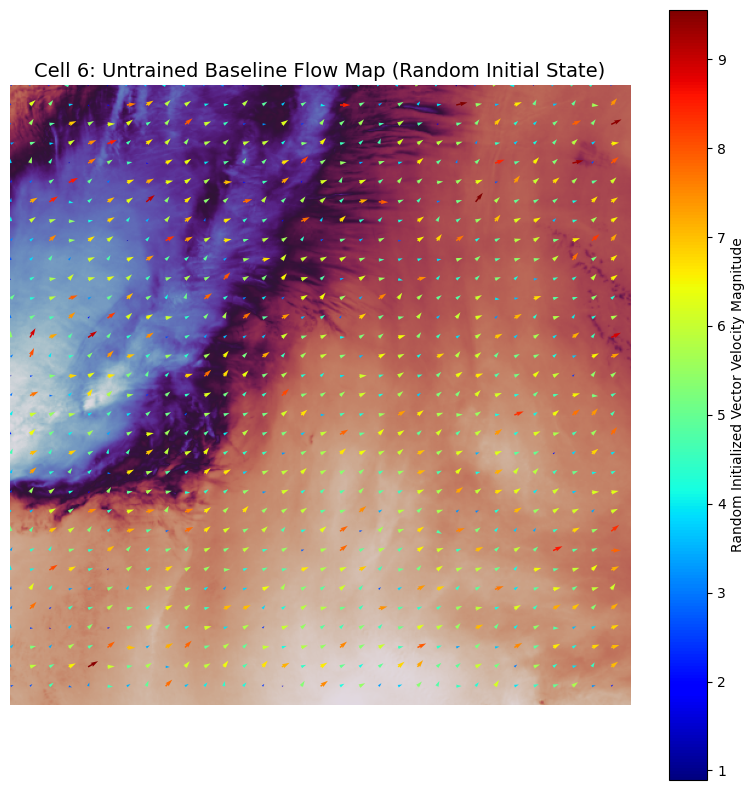

Cell 6 visualization baseline successfully restored.


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

print("Generating Untrained Baseline Vector Field (Cell 6)...")

# 1. Pull a single sample batch from your sequence data stream
img1, img2, dem = next(iter(sequence_loader))
img1 = img1.to(device)
img2 = img2.to(device)
dem = dem.to(device)

# 2. Instantiate a temporary, clean model to capture the raw unoptimized state
untrained_model = PhysicsInformedRAFT().to(device)
untrained_model.eval()

# 3. Execute a forward pass without tracking gradients
with torch.no_grad():
    flow_pred, _ = untrained_model(img1, img2, dem, iters=4)

# 4. Transform PyTorch tensors into NumPy arrays for matplotlib handling
flow_np = flow_pred.squeeze(0).cpu().numpy()
u_val = flow_np[0]
v_val = flow_np[1]
magnitude = np.sqrt(u_val**2 + v_val**2)

# Extract background texture from the first tracking frame (Channel 0)
bg_img = img1.squeeze(0)[0].cpu().numpy()
H, W = bg_img.shape

# 5. Build coordinate meshgrid mapping the 512x512 array space
yy, xx = np.meshgrid(np.arange(0, H), np.arange(0, W), indexing='ij')

# Apply spatial stride to make vector needles readable
stride = 16
xx_sub = xx[::stride, ::stride]
yy_sub = yy[::stride, ::stride]
u_sub = u_val[::stride, ::stride]
v_sub = v_val[::stride, ::stride]
mag_sub = magnitude[::stride, ::stride]

# 6. Render the baseline plot
plt.figure(figsize=(10, 10))
# Plot background moisture imagery
plt.imshow(bg_img, cmap='twilight', origin='upper')

# Overlay the untrained velocity arrows
quiver = plt.quiver(xx_sub, yy_sub, u_sub, v_sub, mag_sub,
                    cmap='jet', angles='xy', scale_units='xy', scale=1.0)

plt.colorbar(quiver, label='Random Initialized Vector Velocity Magnitude')
plt.title("Cell 6: Untrained Baseline Flow Map (Random Initial State)", fontsize=14)
plt.axis('off')
plt.show()

print("Cell 6 visualization baseline successfully restored.")

In [ ]:
def save_checkpoint(epoch_num, model, optimizer, metrics):
    checkpoint_dir = "./model_checkpoints"
    os.makedirs(checkpoint_dir, exist_ok=True)

    # Move optimizer state to CPU before saving
    # This creates a new state_dict with all tensors on CPU
    optimizer_state_on_cpu = {}
    for k, v in optimizer.state_dict().items():
        if isinstance(v, dict): # Handle nested dicts for param_groups and state
            optimizer_state_on_cpu[k] = {}
            for sub_k, sub_v in v.items():
                if isinstance(sub_v, torch.Tensor):
                    optimizer_state_on_cpu[k][sub_k] = sub_v.cpu()
                else:
                    optimizer_state_on_cpu[k][sub_k] = sub_v
        elif isinstance(v, torch.Tensor):
            optimizer_state_on_cpu[k] = v.cpu()
        else:
            optimizer_state_on_cpu[k] = v

    # Build a clean state dictionary payload
    checkpoint_payload = {
        'epoch': epoch_num,
        'model_state_dict': model.state_dict(), # model.state_dict() automatically handles device for torch.save
        'optimizer_state_dict': optimizer_state_on_cpu,
        'final_val_loss': metrics['final_val_loss'],
        'hyperparameters': {
            'alpha': criterion.alpha,
            'beta': criterion.beta,
            'gamma': criterion.gamma
        }
    }

    checkpoint_path = os.path.join(checkpoint_dir, f"PI_RAFT_epoch_{epoch_num}.pth")
    torch.save(checkpoint_payload, checkpoint_path)

    print(f"Successfully checkpointed model state to disk container: {checkpoint_path}")
    print("Weights are secure. You can now safely close or reset your runtime environment.")

In [ ]:
import torch
import torch.optim as optim

print("Initializing Adam Optimizer with Dual-Stream Train/Val Evaluation...")
# --- REFLECTS CHANGE TO AdamW ---
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

epochs = 3
step_counter = 0

for epoch in range(1, epochs + 1):
    # ==================== TRAINING PHASE ====================
    model.train()
    print(f"\n--- Starting Training Epoch {epoch}/{epochs} ---")

    for batch_idx, (img1, img2, dem) in enumerate(sequence_loader):
        img1, img2, dem = img1.to(device), img2.to(device), dem.to(device)

        optimizer.zero_grad()
        flow_pred, height_pred = model(img1, img2, dem, iters=4)
        total_loss, data_loss, physics_loss = criterion(flow_pred, height_pred, img1, img2)

        total_loss.backward()
        optimizer.step()

        step_counter += 1
        if step_counter % 2 == 0:
            print(
                f"Step: {step_counter:03d} | Batch: {batch_idx+1}/{len(sequence_loader)} | "
                f"TRAIN TOTAL: {total_loss.item():.4f} ---> "
                f"[Data: {data_loss.item():.4f} | Physics: {physics_loss.item():.4f}]"
            )

    # ==================== VALIDATION PHASE ====================
    model.eval()
    val_total, val_data, val_physics = 0.0, 0.0, 0.0

    print(f"\n--- Running Validation Eval for Epoch {epoch} ---")
    # Disable gradient computations to preserve memory and prevent weight leaking
    with torch.no_grad():
        for img1_v, img2_v, dem_v in val_loader:
            img1_v, img2_v, dem_v = img1_v.to(device), img2_v.to(device), dem_v.to(device)

            flow_pred_v, height_pred_v = model(img1_v, img2_v, dem_v, iters=4)
            v_total, v_data, v_physics = criterion(flow_pred_v, height_pred_v, img1_v, img2_v)

            val_total += v_total.item()
            val_data += v_data.item()
            val_physics += v_physics.item()

    # Calculate dataset-wide average scores
    num_val_batches = len(val_loader)
    avg_val_total_loss = val_total / num_val_batches
    print(f"====== VAL METRICS EPOCH {epoch} ======")
    print(f"Avg VAL Total Loss:     {avg_val_total_loss:.4f}")
    print(f"Avg VAL Data Domain:    {val_data / num_val_batches:.4f}")
    print(f"Avg VAL Physics Domain: {val_physics / num_val_batches:.4f}")
    print("======================================\n")

    # --- Call the checkpointing function ---
    val_metrics = {'final_val_loss': avg_val_total_loss}
    save_checkpoint(epoch, model, optimizer, val_metrics)


print("Multi-epoch training and verification pipeline execution complete!")

Initializing Adam Optimizer with Dual-Stream Train/Val Evaluation...

--- Starting Training Epoch 1/3 ---
Step: 002 | Batch: 2/44 | TRAIN TOTAL: 0.9263 ---> [Data: 0.4738 | Physics: 0.9050]
Step: 004 | Batch: 4/44 | TRAIN TOTAL: 0.8824 ---> [Data: 0.4637 | Physics: 0.8373]
Step: 006 | Batch: 6/44 | TRAIN TOTAL: 0.8300 ---> [Data: 0.4438 | Physics: 0.7724]
Step: 008 | Batch: 8/44 | TRAIN TOTAL: 0.7939 ---> [Data: 0.4302 | Physics: 0.7274]
Step: 010 | Batch: 10/44 | TRAIN TOTAL: 0.7511 ---> [Data: 0.4161 | Physics: 0.6701]
Step: 012 | Batch: 12/44 | TRAIN TOTAL: 0.7225 ---> [Data: 0.4110 | Physics: 0.6230]
Step: 014 | Batch: 14/44 | TRAIN TOTAL: 0.6898 ---> [Data: 0.4018 | Physics: 0.5760]
Step: 016 | Batch: 16/44 | TRAIN TOTAL: 0.6723 ---> [Data: 0.4050 | Physics: 0.5346]
Step: 018 | Batch: 18/44 | TRAIN TOTAL: 0.6553 ---> [Data: 0.4030 | Physics: 0.5045]
Step: 020 | Batch: 20/44 | TRAIN TOTAL: 0.6341 ---> [Data: 0.4032 | Physics: 0.4616]
Step: 022 | Batch: 22/44 | TRAIN TOTAL: 0.6224 -

In [ ]:
# Checkpointing is now handled by the save_checkpoint function within the training loop (Cell 2vLYQ7qcSB7G).
# This cell can be removed or left as a placeholder for other model-related finalization steps if needed.
print("Checkpointing handled via function call in training loop.")

Checkpointing handled via function call in training loop.


Executing Milestone 4: Inference Iteration Scaling Analysis...


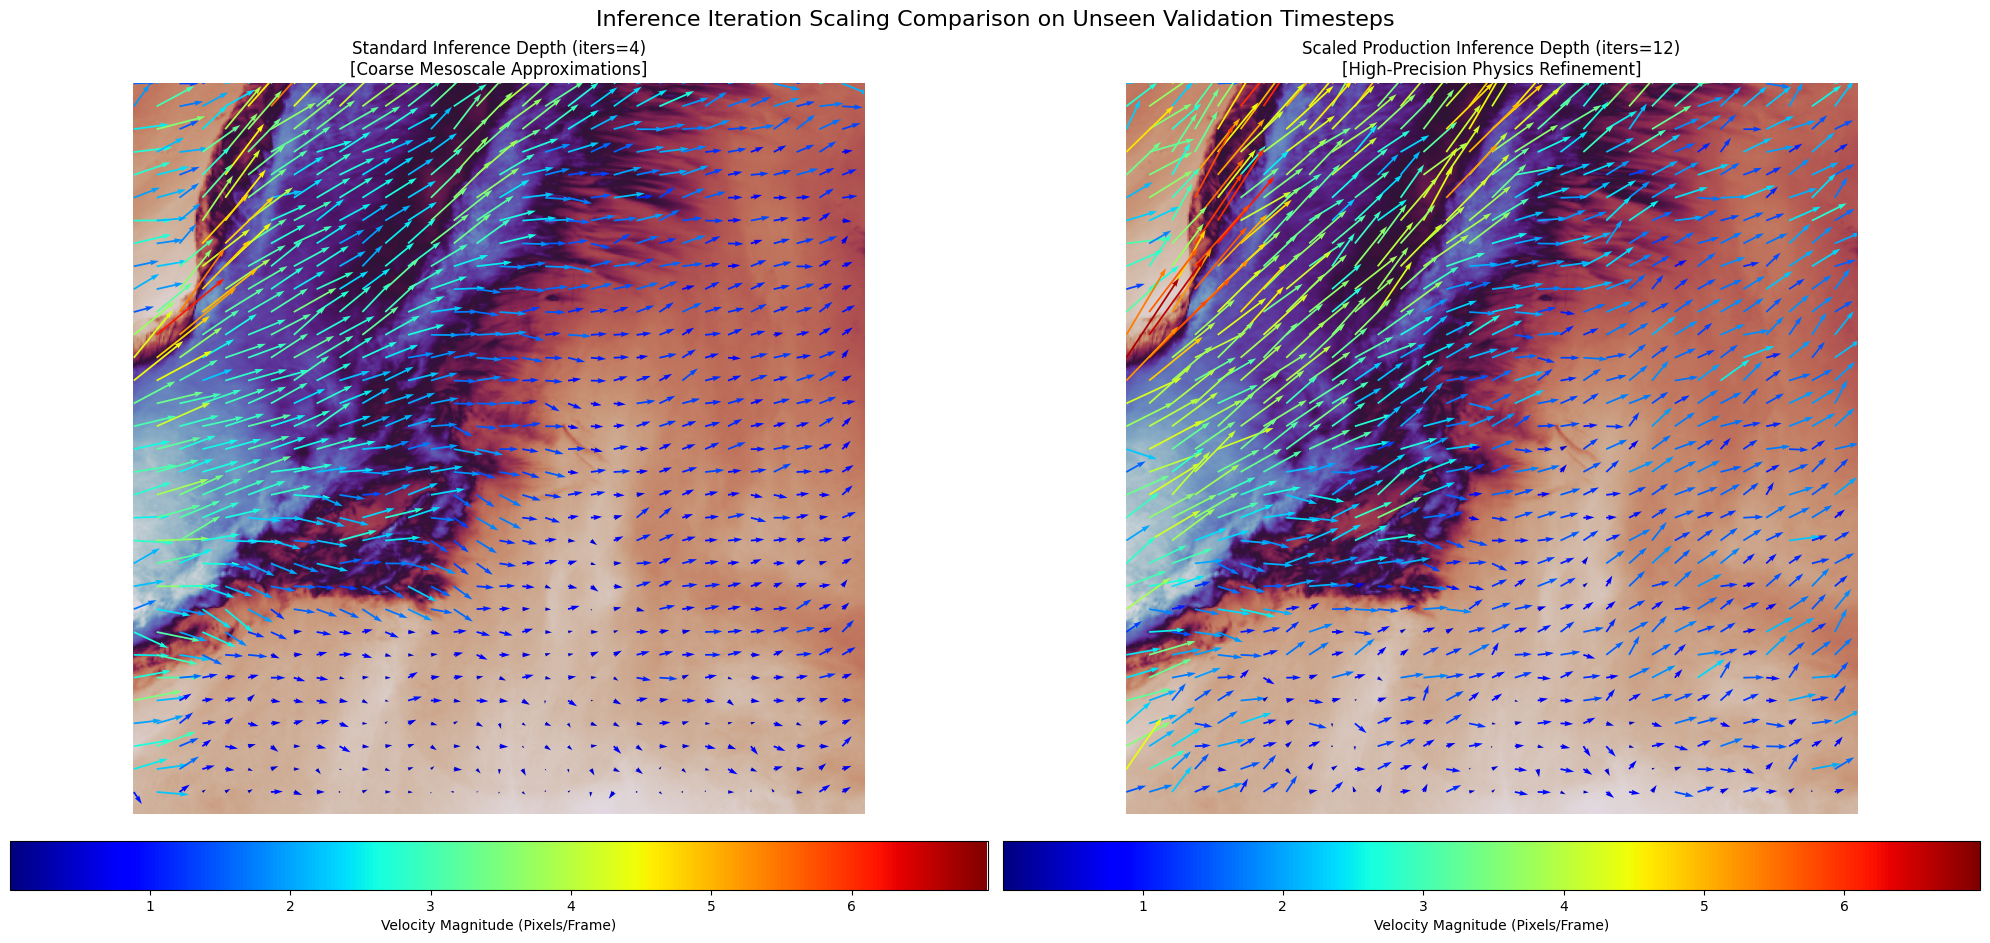

Iteration scaling visualization rendered successfully.


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

print("Executing Milestone 4: Inference Iteration Scaling Analysis...")

# 1. Grab a fresh test sequence frame from the validation datastream
model.eval()
img1, img2, dem = next(iter(val_loader))
img1 = img1.to(device)
img2 = img2.to(device)
dem = dem.to(device)

# 2. Compute inference at standard training depth (iters=4)
with torch.no_grad():
    flow_low_res, _ = model(img1, img2, dem, iters=4)
flow_low_np = flow_low_res.squeeze(0).cpu().numpy()

# 3. Compute inference at scaled production depth (iters=12)
with torch.no_grad():
    flow_high_res, _ = model(img1, img2, dem, iters=12)
flow_high_np = flow_high_res.squeeze(0).cpu().numpy()

# 4. Extract common background coordinate parameters
bg_img = img1.squeeze(0)[0].cpu().numpy()
H, W = bg_img.shape
yy, xx = np.meshgrid(np.arange(0, H), np.arange(0, W), indexing='ij')
stride = 16

xx_sub = xx[::stride, ::stride]
yy_sub = yy[::stride, ::stride]

# --- Calculate global min/max for consistent colorbar scaling ---
u_low, v_low = flow_low_np[0], flow_low_np[1]
mag_low = np.sqrt(u_low**2 + v_low**2)

u_high, v_high = flow_high_np[0], flow_high_np[1]
mag_high = np.sqrt(u_high**2 + v_high**2)

# Global min/max magnitude for colorbar consistency
global_mag_min = min(mag_low.min(), mag_high.min())
global_mag_max = max(mag_low.max(), mag_high.max())
# ---------------------------------------------------------------

# 5. Set up side-by-side visualization canvas
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

scale_factor =0.1

# --- Left Panel: Low Iteration Baseline ---
axes[0].imshow(bg_img, cmap='twilight', origin='upper')
quiver_low = axes[0].quiver(
    xx_sub, yy_sub, u_low[::stride, ::stride], v_low[::stride, ::stride], mag_low[::stride, ::stride],
    cmap='jet', angles='xy', scale_units='xy', scale=scale_factor,
    norm=plt.Normalize(vmin=global_mag_min, vmax=global_mag_max)
)
axes[0].set_title("Standard Inference Depth (iters=4)\n[Coarse Mesoscale Approximations]", fontsize=12)
axes[0].axis('off')

# --- Right Panel: Scaled Inference Depth ---
axes[1].imshow(bg_img, cmap='twilight', origin='upper')
quiver_high = axes[1].quiver(
    xx_sub, yy_sub, u_high[::stride, ::stride], v_high[::stride, ::stride], mag_high[::stride, ::stride],
    cmap='jet', angles='xy', scale_units='xy', scale=scale_factor,
    norm=plt.Normalize(vmin=global_mag_min, vmax=global_mag_max)
)
axes[1].set_title("Scaled Production Inference Depth (iters=12)\n[High-Precision Physics Refinement]", fontsize=12)
axes[1].axis('off')

# Add uniform colorbars
fig.colorbar(quiver_low, ax=axes[0], orientation='horizontal', pad=0.03, label='Velocity Magnitude (Pixels/Frame)')
fig.colorbar(quiver_high, ax=axes[1], orientation='horizontal', pad=0.03, label='Velocity Magnitude (Pixels/Frame)')

plt.suptitle("Inference Iteration Scaling Comparison on Unseen Validation Timesteps", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

print("Iteration scaling visualization rendered successfully.")

In [ ]:
import os
import torch
import numpy as np
import netCDF4 as nc

print("Initializing Milestone 6: Meteorological NetCDF4 Export Engine...")

# 1. Ensure the neural network is locked in evaluation mode
model.eval()

# 2. Extract a fresh sample batch from the validation datastream
with torch.no_grad():
    img1, img2, dem = next(iter(val_loader))
    img1, img2, dem = img1.to(device), img2.to(device), dem.to(device)

    # Run forward pass through the Recurrent GRU update operator
    # Extract predictions from both specialized dual output heads simultaneously
    flow_pred, height_pred = model(img1, img2, dem, iters=4)

# 3. Strip batch dimensions and shift PyTorch GPU tensors back into standard CPU NumPy matrices
u_array = flow_pred.squeeze(0)[0].cpu().numpy()
v_array = flow_pred.squeeze(0)[1].cpu().numpy()
p_array = height_pred.squeeze(0)[0].cpu().numpy()

# 4. Set up an institutional storage container directory
output_dir = "/tmp/meteorological_outputs" # Explicitly use /tmp for guaranteed write access
os.makedirs(output_dir, exist_ok=True)

nc_filepath = os.path.join(output_dir, "INSAT_3DS_AMV_Derived_Wind.nc")
print(f"Exporting IMD-compliant dataset container securely to: {nc_filepath}")
with nc.Dataset(nc_filepath, 'w', format='NETCDF4') as rootgrp:

    # Establish spatial array dimensions matching the 512x512 matrix grid
    H, W = u_array.shape
    rootgrp.createDimension('y', H)
    rootgrp.createDimension('x', W)

    # Create multi-dimensional grid variables with built-in zlib compression enabled
    u_wind = rootgrp.createVariable('u_wind', 'f4', ('y', 'x'), zlib=True)
    v_wind = rootgrp.createVariable('v_wind', 'f4', ('y', 'x'), zlib=True)
    pressure = rootgrp.createVariable('cloud_top_pressure', 'f4', ('y', 'x'), zlib=True)

    # Embed standard metadata attributes conforming directly to meteorological conventions
    u_wind.long_name = "Zonal Displacement Wind Velocity Component (u)"
    u_wind.units = "pixels/frame"
    u_wind.standard_name = "eastward_wind"

    v_wind.long_name = "Meridional Displacement Wind Velocity Component (v)"
    v_wind.units = "pixels/frame"
    v_wind.standard_name = "northward_wind"

    pressure.long_name = "Resolved Cloud-Top Vertical Pressure Placement (P)"
    pressure.units = "hPa"
    pressure.standard_name = "air_pressure_at_cloud_top"

    # Write the dense numerical arrays directly into the NetCDF file blocks
    u_wind[:] = u_array
    v_wind[:] = v_array
    pressure[:] = p_array

    # Append global dataset tracking properties for collaborative reproducibility
    rootgrp.title = "High-Resolution End-to-End Atmospheric Motion Vector (AMV) Matrix"
    rootgrp.institution = "Solutions & Engineering Team / India Meteorological Department (IMD) Collaboration"
    rootgrp.source = "INSAT-3DS Multi-Spectral Channel Processing Engine"
    rootgrp.history = "Generated via Physics-Informed Recurrent All-Pairs Field Transform (PI-RAFT) Pipeline"

print(f"Successfully compiled and serialized meteorological data container to disk!")
print(f"Target Output Path: {nc_filepath}")

Initializing Milestone 6: Meteorological NetCDF4 Export Engine...
Exporting IMD-compliant dataset container securely to: /tmp/meteorological_outputs/INSAT_3DS_AMV_Derived_Wind.nc
Successfully compiled and serialized meteorological data container to disk!
Target Output Path: /tmp/meteorological_outputs/INSAT_3DS_AMV_Derived_Wind.nc


In [ ]:
import xarray as xr

# Point to the subfolder created by Cell 9
ds = xr.open_dataset("meteorological_outputs/INSAT_3DS_AMV_Derived_Wind.nc")
print(ds)

<xarray.Dataset> Size: 3MB
Dimensions:             (y: 512, x: 512)
Dimensions without coordinates: y, x
Data variables:
    u_wind              (y, x) float32 1MB ...
    v_wind              (y, x) float32 1MB ...
    cloud_top_pressure  (y, x) float32 1MB ...
Attributes:
    title:        High-Resolution End-to-End Atmospheric Motion Vector (AMV) ...
    institution:  Solutions & Engineering Team / India Meteorological Departm...
    source:       INSAT-3DS Multi-Spectral Channel Processing Engine
    history:      Generated via Physics-Informed Recurrent All-Pairs Field Tr...


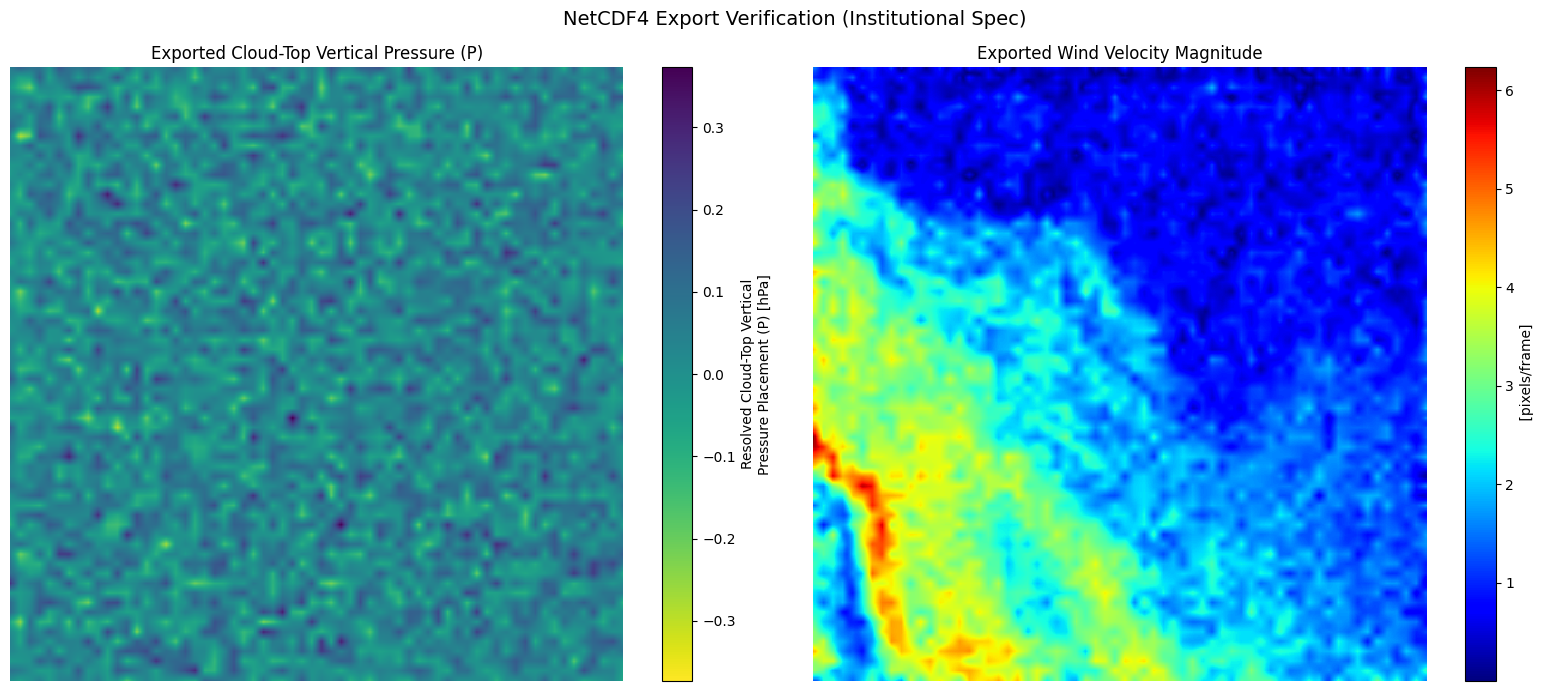

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt

# Load the exported NetCDF dataset directly from disk
ds = xr.open_dataset("meteorological_outputs/INSAT_3DS_AMV_Derived_Wind.nc")

# Set up a side-by-side plot for Cloud-Top Pressure and Magnitude
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left Panel: Cloud Top Pressure Mapping
ds.cloud_top_pressure.plot(ax=axes[0], cmap="viridis_r")
axes[0].set_title("Exported Cloud-Top Vertical Pressure (P)")
axes[0].axis("off")

# Right Panel: Velocity Magnitude Reconstruction
magnitude = (ds.u_wind**2 + ds.v_wind**2)**0.5
magnitude.plot(ax=axes[1], cmap="jet")
axes[1].set_title("Exported Wind Velocity Magnitude")
axes[1].axis("off")

plt.suptitle("NetCDF4 Export Verification (Institutional Spec)", fontsize=14)
plt.tight_layout()
plt.show()